# Chapter 6: The Price of a Choice

A document is ready for release, but the controller still has to choose what happens next. Releasing can produce a useful result or an expensive mistake. Review avoids some uncertainty but consumes resources. Abstention preserves the current state and can also carry an opportunity cost. The relevant question is not which action sounds most confident. It is which action has the greatest value under the probabilities and consequences you are prepared to defend.

This laboratory makes that boundary inspectable. The release action has two outcomes. Review and abstention have their own rows rather than hiding inside a verbal recommendation. The numbers are constructed teaching inputs. They are not measurements of a publisher, an assistant, or a review team. You can replace them with your own stated probabilities and valuations, then see exactly which part of the recommendation changes.

Before executing anything, multiply each outcome probability by its utility. Add the products and subtract the action cost. Notice that a small probability can matter greatly when the corresponding loss is large. Keep that observation beside the chart: the height of each action's point on the utility plot depends on both belief and stakes.

**Outcome:** Return an expected-utility choice and a break-even value under declared stakes.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later and the packages in `requirements.txt` at the top of the repository. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- Weighted averages

## The question and its mathematics

For an action a with mutually exclusive outcomes o, the expected utility is EU(a)=sum_o P(o|a)u(o,a)-c(a). The outcome probabilities in each row must sum to one. Utilities need not be positive, and they need not use money, but all alternatives must share the same utility scale. A unit of benefit cannot be added to an hour of delay until you state how those quantities enter one valuation.

The selected action is an argmax of this expected utility over the supplied action set. This is a decision rule under declared values, not a claim that those values are correct. Expected loss is the negative of expected utility in this implementation. It is not a second independent objective or an estimate of physical harm.

A break-even calculation exposes sensitivity. Let p be the probability of the first outcome of the first action, v its unknown utility, B the weighted utility of its other outcomes, c its cost, and A the best alternative's expected utility. The equality pv+B-c=A gives v=(A+c-B)/p when p is positive. At p=0 that utility cannot affect the choice, so the threshold is unavailable.

For a two-outcome first action, the probability curve holds both outcome utilities fixed and varies p. Its slope is the difference between those utilities. A steep line indicates strong sensitivity to probability calibration. The curve does not estimate p; it shows what would follow if p took each plotted value.

## A calculation you can run

The input is an action table, encoded as JSON. Each row supplies a unique action name, its probability vector, a utility vector of the same length, and an optional nonnegative cost. Validation rejects nonfinite numbers, negative probabilities, totals that differ from one, and vectors that do not align. These checks prevent a plausible-looking average from concealing an invalid outcome space.

The computation creates one row per alternative with expected utility, expected loss, and cost. It selects the greatest expected utility and reports the first-outcome break-even utility against the best remaining alternative. Ties follow the input order; if a tie needs a different operational policy, define that policy before acting. The action plot marks each action by name on the horizontal axis, in input order, and shows utility units on the vertical axis; the markers are joined by a line only to show order, not a trend. Consult the returned table for action names.

A second figure appears when the first action has exactly two outcomes. It varies the first-outcome probability while assigning the remaining probability to the second outcome. Compare this sensitivity line with the constant value of the preferred alternative. For the changed case, alter the severe loss while preserving the probabilities. That isolates a stakes change from a belief change.

The next cell finds the repository root and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file() and (p / "src" / "math_ai_agents").is_dir()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from a clone of the math-ai-agents repository.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 6
inputs = {'actions': [{'name': 'release',
              'probabilities': [0.9, 0.1],
              'utilities': [10, -50],
              'cost': 0},
             {'name': 'review', 'probabilities': [1], 'utilities': [2], 'cost': 0},
             {'name': 'abstain', 'probabilities': [1], 'utilities': [0], 'cost': 0}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 6: expected-utility
Should this controller release, request review, or abstain?
Evidence: constructed teaching example

Calculated quantities:
{
  "selected_action": "release",
  "expected_utility": 4.0,
  "break_even_first_utility": 7.777777778
}

Interpretation:
The selected action maximizes the declared expected utility, including any abstention row.

Assumptions:
- Utilities and probabilities are supplied judgments.
- One decision, mutually exclusive outcomes per action.

Limitations:
- No objective valuation or calibrated probability is inferred.

Execution: completed locally; constructed inputs are not deployment measurements.


The release row has expected utility 0.9(10)+0.1(-50)=4. Review has utility 2 and abstention has utility 0, so release wins under these inputs. Its expected loss is -4 because loss is defined here as negative utility. A negative reported loss is therefore a favorable valuation, not a negative count of adverse events.

The first-outcome utility needed to tie review is (2+5)/0.9, approximately 7.78. The supplied value 10 exceeds that threshold. When the failure utility changes to -100, release falls to -1 while review stays at 2. The recommendation reverses without changing the model's probability of success. Read this as a statement about the action contract, not as evidence that the controller became less capable.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

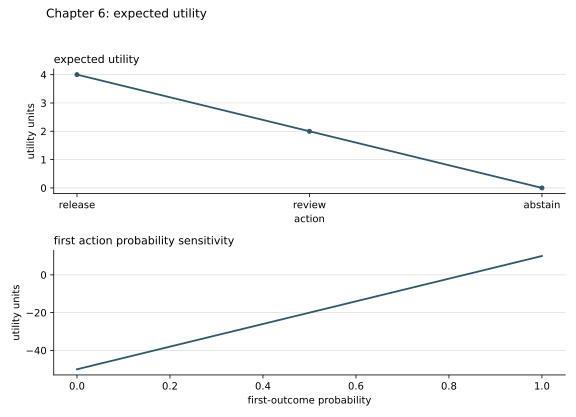

In [3]:
display(SVG(figure_svg(report)))

**Figure 6.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

An expected-utility winner can be the wrong action for an incompletely specified decision. A prohibited release must first be removed from the feasible action set. Assigning it a large negative utility is not equivalent to enforcing a hard permission boundary. Likewise, an outcome labeled success can hide costs imposed on someone outside the table. If those costs matter to the decision, they need a declared valuation or a separate constraint.

The failure experiment in this notebook is a changed loss, not an adversarially chosen probability. It demonstrates that a high success probability does not settle the choice. A second useful test is to set the first-outcome probability to zero. The break-even first utility becomes unavailable because no value assigned to an impossible outcome can change expected utility. Returning zero as a threshold would manufacture information.

Probability estimates also deserve their own evidence. A row containing 0.9 is a statement of belief until a calibration or measurement protocol supports it. The arithmetic can be exact while the decision remains sensitive to a poorly supported input. Keep the probability source and utility owner in the exported report.

Chapter 6: expected-utility
Should this controller release, request review, or abstain?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "selected_action": "review",
  "expected_utility": 2.0,
  "break_even_first_utility": 13.33333333
}

Interpretation:
The selected action maximizes the declared expected utility, including any abstention row.

Assumptions:
- Utilities and probabilities are supplied judgments.
- One decision, mutually exclusive outcomes per action.

Limitations:
- No objective valuation or calibrated probability is inferred.

Execution: completed locally; constructed inputs are not deployment measurements.


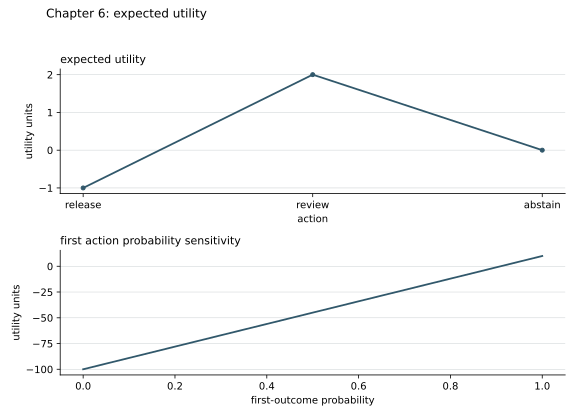

In [4]:
changed_inputs = {'actions': [{'name': 'release',
              'probabilities': [0.9, 0.1],
              'utilities': [10, -100],
              'cost': 0},
             {'name': 'review', 'probabilities': [1], 'utilities': [2], 'cost': 0},
             {'name': 'abstain', 'probabilities': [1], 'utilities': [0], 'cost': 0}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 6.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case compares retry with escalation. Retry's expected utility is 0.7(8)+0.3(-12)-1=1, which ties escalation at 1. Because retry appears first, the implementation selects it. That tie is useful: the calculation identifies an operational choice that the valuation does not uniquely resolve.

Replace the table with a local action contract whose outcomes are mutually exclusive and collectively exhaustive. Include the cost of waiting, asking for help, or preserving the current state when those are real alternatives. After execution, report the winning value and the runner-up, then identify the input whose plausible change would reverse them. Do not export the selected label alone. A decision record should preserve why it won and which assumptions made the comparison possible.

In [5]:
transfer_inputs = {'actions': [{'name': 'retry',
              'probabilities': [0.7, 0.3],
              'utilities': [8, -12],
              'cost': 1},
             {'name': 'escalate', 'probabilities': [1], 'utilities': [1], 'cost': 0}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 6: expected-utility
Should this controller release, request review, or abstain?
Evidence: constructed transfer example

Calculated quantities:
{
  "selected_action": "retry",
  "expected_utility": 1.0,
  "break_even_first_utility": 8.0
}

Interpretation:
The selected action maximizes the declared expected utility, including any abstention row.

Assumptions:
- Utilities and probabilities are supplied judgments.
- One decision, mutually exclusive outcomes per action.

Limitations:
- No objective valuation or calibrated probability is inferred.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **actions:** Nonempty list of uniquely named alternatives. Each has name:string, probabilities:normalized numeric list, utilities:aligned finite numeric list, cost:nonnegative number. Include abstention explicitly.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch06.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 6: expected-utility
Should this controller release, request review, or abstain?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "selected_action": "retry",
  "expected_utility": 1.0,
  "break_even_first_utility": 8.0
}

Interpretation:
The selected action maximizes the declared expected utility, including any abstention row.

Assumptions:
- Utilities and probabilities are supplied judgments.
- One decision, mutually exclusive outcomes per action.

Limitations:
- No objective valuation or calibrated probability is inferred.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. Calculate release utility in the default case.

2. What first-outcome probability ties review under the default utilities?

3. Why does the transfer case not have a unique utility winner?

Answers: [separate solutions](../solutions/ch06.md). Try the calculation before opening them.

## Summary

Expected utility combines probabilities, consequences, and costs on a shared scale. This notebook returns an inspectable choice, its alternatives, and a break-even utility. The changed case shows a stakes-driven reversal; the transfer case shows a tie that needs an operational rule. None of those results calibrates the probabilities or authorizes an action. Use the calculation to expose the decision boundary, then apply the actual permissions and constraints before execution. When a value or probability is disputed, preserve that disagreement as an input range and inspect sensitivity rather than pretending the selected row is an objective fact.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The matching skill is [`skills/06-expected-utility`](../skills/06-expected-utility/). It uses this notebook's computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 6.1

![Equation 6.1](../assets/math/5be7ec724fae81adf423.svg)

Equation (6.1) converts a ranking of outcomes into numbers, so that comparisons the system could already make become arithmetic it can do.

One outcome is preferred to another exactly when the first is assigned the larger number.

LaTeX source, preserved for inspection:

```latex
y_1 \succ y_2 \iff u(y_1) > u(y_2).
\tag{6.1}
```

### Equation 6.2

![Equation 6.2](../assets/math/239d97ab52b608b1b761.svg)

Equation (6.2) collapses an entire distribution over outcomes into the single number an agent needs in order to compare one action against another.

For the action under consideration, multiply each outcome's worth by its probability under that action, then add the products.

LaTeX source, preserved for inspection:

```latex
\operatorname{EU}(a)=\sum_{y}p(y\mid a)\,u(y).
\tag{6.2}
```

### Equation 6.3

![Equation 6.3](../assets/math/3b4eb1e76781ca7fa986.svg)

Equation (6.3) states the rule the rest of this book's decision-making rests on: take the action whose expected utility is highest.

Compute the expected utility of every available action, then select the action achieving the maximum.

LaTeX source, preserved for inspection:

```latex
a^{\star}=\arg\max_{a\in\mathcal{A}}\operatorname{EU}(a).
\tag{6.3}
```

### Equation 6.4

![Equation 6.4](../assets/math/0548bb8cbea42c084933.svg)

Equation (6.4) defines the certain amount an agent would accept in place of a gamble, which turns an attitude toward risk into a measurable quantity.

Find the guaranteed outcome whose worth equals the average worth of the gamble; that outcome is the certainty equivalent.

LaTeX source, preserved for inspection:

```latex
u(\operatorname{CE})=\operatorname{E}\!\left[u(Y)\right].
\tag{6.4}
```